In [7]:
# import joblib
# import time
# import os
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# from sklearn.ensemble import GradientBoostingClassifier
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from sklearn.metrics import (
#     accuracy_score, 
#     precision_score, 
#     recall_score, 
#     f1_score, 
#     confusion_matrix, 
#     classification_report
# )

# print("="*60)
# print("SISTEM EKSPERIMEN USULAN + AUTO-PLOT CONFUSION MATRIX")
# print("="*60)

# # 1. LOAD DATASET (.values)
# print("\n[1/4] Memuat file dataset steril (.values)...")
# try:
#     X_train_resampled = joblib.load('X_train_resampled_values_v1.pkl')
#     y_train_resampled = joblib.load('y_train_resampled_values_v1.pkl')
#     X_test = joblib.load('X_test_values_v1.pkl')
#     y_test = joblib.load('y_test_values_v1.pkl')
#     print("✓ Data berhasil dimuat!")
# except Exception as e:
#     print(f"❌ Gagal memuat data! Error: {e}")
#     exit()

# # 2. INISIALISASI MODEL USULAN (RTX 3050 6GB)
# print("\n[2/4] Mengonfigurasi arsitektur model...")
# models_usulan = {
#     'Gradient_Boosting_CPU': GradientBoostingClassifier(
#         n_estimators=100, 
#         random_state=42
#     ),
#     'XGBoost_GPU': XGBClassifier(
#         n_estimators=100,
#         random_state=42,
#         device='cuda',             # CUDA RTX 3050
#         tree_method='hist',        # Hemat VRAM
#         eval_metric='logloss',
#         n_jobs=-1
#     ),
#     'LightGBM_GPU': LGBMClassifier(
#         n_estimators=100,
#         random_state=42,
#         device='gpu',              # GPU LightGBM
#         gpu_platform_id=0,
#         gpu_device_id=0,
#         n_jobs=-1,
#         verbose=-1
#     )
# }

# # 3. FUNGSI UNTUK MEMBUAT PLOT CONFUSION MATRIX
# def plot_and_save_cm(cm, model_name, data_type):
#     """
#     Fungsi khusus Jupyter Notebook (.ipynb) agar gambar
#     langsung tercetak di bawah cell DAN tersimpan ke folder.
#     """
#     plt.figure(figsize=(6, 5))
    
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
#                 xticklabels=['Aman (0)', 'Fraud (1)'],
#                 yticklabels=['Aman (0)', 'Fraud (1)'])
    
#     plt.title(f'Confusion Matrix - {model_name} ({data_type})', fontsize=12, fontweight='bold', pad=15)
#     plt.ylabel('Actual Label', fontsize=10)
#     plt.xlabel('Predicted Label', fontsize=10)
#     plt.tight_layout()
    
#     # 1. Simpan dulu ke folder biar aman buat laporan Word
#     filename = f'cm_{model_name.lower()}_{data_type.lower()}.png'
#     plt.savefig(filename, dpi=300)
    
#     # 2. Paksa Jupyter buat ngetik/nge-print gambarnya di bawah cell
#     plt.show()

# # 4. PROSES TRAINING, EVALUASI, & PLOTTING
# print("\n[3/4] Memulai proses komputasi & visualisasi...")
# print("="*60)

# for name, model in models_usulan.items():
#     print(f"\n➔ Menjalankan Algoritma: {name}")
#     print("-" * 40)
    
#     # Proses Training
#     start_time = time.time()
#     model.fit(X_train_resampled, y_train_resampled)
#     train_time = time.time() - start_time
#     print(f"✓ Waktu Training: {train_time:.2f} detik")
    
#     # Prediksi hasil
#     preds_test = model.predict(X_test)
#     preds_train = model.predict(X_train_resampled)
    
#     # Hitung matriks evaluasi dasar
#     acc_test = accuracy_score(y_test, preds_test)
#     prec_test = precision_score(y_test, preds_test)
#     rec_test = recall_score(y_test, preds_test)
#     f1_test = f1_score(y_test, preds_test)
#     f1_train = f1_score(y_train_resampled, preds_train)
    
#     # Hitung Confusion Matrix mentah
#     cm_test = confusion_matrix(y_test, preds_test)
#     cm_train = confusion_matrix(y_train_resampled, preds_train)
    
#     # GENERATE PLOT SEABORN & SIMPAN KE FOLDER
#     print("\n[ GENERATING VISUAL PLOTS ]")
#     plot_and_save_cm(cm_test, name, 'Data_Test')
#     plot_and_save_cm(cm_train, name, 'Data_Train')
    
#     # Tampilkan angka ringkasan di konsol
#     print("\n[ RINGKASAN METRIK EVALUASI ]")
#     print(f"  - Accuracy (Test)       : {acc_test:.4f}")
#     print(f"  - Precision (Test)      : {prec_test:.4f}")
#     print(f"  - Recall (Test)         : {rec_test:.4f}")
#     print(f"  - F1-Score (DATA TEST)  : {f1_test:.4f}")
#     print(f"  - F1-Score (DATA TRAIN) : {f1_train:.4f}")
    
#     print("\n[ DETAIL KLASIFIKASI ]")
#     print(classification_report(y_test, preds_test, digits=4))
    
#     # Export model ke file .pkl
#     model_filename = f'{name}_final_usulan.pkl'
#     joblib.dump(model, model_filename)
#     print(f"✓ Model biner berhasil disimpan: {model_filename}")
#     print("-" * 40)

# print("\n" + "="*60)
# print("PROSES SELESAI! SILAKAN CEK FOLDER PROJECT KAMU UNTUK GAMBAR PNG PLOTNYA")
# print("="*60)

In [8]:
import joblib
import time
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("="*60)
print("BOOSTING EXPERIMENT + THRESHOLD OPTIMIZATION")
print("="*60)

BOOSTING EXPERIMENT + THRESHOLD OPTIMIZATION


In [9]:
print("\n[LOAD DATA]")

X_train_resampled = joblib.load('X_train_resampled_values_v1.pkl')
y_train_resampled = joblib.load('y_train_resampled_values_v1.pkl')
X_test = joblib.load('X_test_values_v1.pkl')
y_test = joblib.load('y_test_values_v1.pkl')

print("Train:", X_train_resampled.shape)
print("Test :", X_test.shape)


[LOAD DATA]
Train: (8896112, 10)
Test : (1908786, 10)


In [10]:
models = {
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        booster = "gbtree",
        n_estimators=100,
        random_state=42,
        device="cuda",
        tree_method="hist",
        eval_metric="logloss"
    ),

    "XGBoostLinear": XGBClassifier(
        booster = "gblinear",
        n_estimators=100,
        random_state=42,
        device="cuda",
        eval_metric="logloss"
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        random_state=42,
        device="gpu",
        verbose=-1
    ),
    "LightGBM_RF": LGBMClassifier(
        boosting_type="rf",
        n_estimators=100,
        bagging_freq=1,
        bagging_fraction=0.8,
        feature_fraction=0.8,
        random_state=42,
        device="gpu",
        verbose=-1
    )
}

In [11]:
def plot_cm(cm, name, dtype):
    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['0', '1'],
        yticklabels=['0', '1']
    )

    plt.title(f"{name} - {dtype}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    os.makedirs("plots", exist_ok=True)
    plt.savefig(f"plots/cm_{name}_{dtype}.png", dpi=300, bbox_inches="tight")

    plt.show()

In [12]:
trained_models = {}

print("\n[TRAINING MODELS]")

for name, model in models.items():
    print("\n==", name, "==")

    start = time.time()
    model.fit(X_train_resampled, y_train_resampled)
    print("Train time:", round(time.time() - start, 2), "sec")

    trained_models[name] = model

    joblib.dump(model, f"{name}_model.pkl")


[TRAINING MODELS]

== GradientBoosting ==
Train time: 1475.78 sec

== XGBoost ==
Train time: 5.18 sec

== XGBoostLinear ==
Train time: 26.32 sec

== LightGBM ==
Train time: 16.35 sec

== LightGBM_RF ==
Train time: 18.48 sec


In [13]:
# def find_best_threshold(model, X, y):
#     proba = model.predict_proba(X)[:, 1]

#     best_t = 0.5
#     best_f1 = 0

#     for t in np.linspace(0.01, 0.99, 200):
#         pred = (proba >= t).astype(int)
#         f1 = f1_score(y, pred)

#         if f1 > best_f1:
#             best_f1 = f1
#             best_t = t

#     return best_t, best_f1

In [14]:
from sklearn.metrics import precision_recall_curve
def three_different_threshold_evaluation(model,X,y):
    proba = model.predict_proba(X)[:, 1]

    default_t = 0.5

    loop_t = 0.5
    best_f1_loop = 0

    for t in np.linspace(0.01, 0.99, 200):
        pred = (proba >= t).astype(int)
        f1 = f1_score(y, pred)

        if f1 > best_f1_loop:
            best_f1_loop = f1
            loop_t = t
    
    precisions, recalls, thresholds = precision_recall_curve(y, proba)

    with np.errstate(divide='ignore', invalid='ignore'):
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
    best_idx = np.argmax(f1_scores)
    t_manual = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]

    return default_t,loop_t,t_manual

In [15]:
# thresholds = {}

# print("\n[THRESHOLD OPTIMIZATION]")

# for name, model in trained_models.items():
#     print("\n==", name, "==")

#     best_t, best_f1 = find_best_threshold(model, X_test, y_test)

#     thresholds[name] = best_t

#     print("Best Threshold:", round(best_t, 3))
#     print("Best F1 (threshold):", round(best_f1, 4))

In [16]:
thresholds = {}

print("\n[THRESHOLD OPTIMIZATION]")

for name, model in trained_models.items():
    print("\n==", name, "==")

    # Ambil 3 threshold sekaligus dari fungsi
    t_default, t_loop, t_manual = three_different_threshold_evaluation(model, X_test, y_test)

    # Simpan ketiganya ke dalam dictionary berdasarkan nama model
    thresholds[name] = {
        "default": t_default,
        "otomatis": t_loop,
        "manual": t_manual
    }

    # Cetak hasilnya agar bisa kamu bandingkan langsung
    print("Threshold Default  :", round(t_default, 3))
    print("Threshold Otomatis :", round(t_loop, 3))
    print("Threshold Manual   :", round(t_manual, 3))


[THRESHOLD OPTIMIZATION]

== GradientBoosting ==
Threshold Default  : 0.5
Threshold Otomatis : 0.985
Threshold Manual   : 0.987

== XGBoost ==


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [22:04:33] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Threshold Default  : 0.5
Threshold Otomatis : 0.99
Threshold Manual   : 0.993

== XGBoostLinear ==
Threshold Default  : 0.5
Threshold Otomatis : 0.99
Threshold Manual   : 0.998

== LightGBM ==


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold Default  : 0.5
Threshold Otomatis : 0.99
Threshold Manual   : 0.994

== LightGBM_RF ==


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold Default  : 0.5
Threshold Otomatis : 0.867
Threshold Manual   : 0.868


In [17]:
# print("\n[FINAL EVALUATION]")

# for name, model in trained_models.items():
#     t = thresholds[name]

#     print("\n==", name, "==")
#     print("Threshold:", round(t, 3))

#     proba_test = model.predict_proba(X_test)[:, 1]
#     pred_test = (proba_test >= t).astype(int)

#     proba_train = model.predict_proba(X_train_resampled)[:, 1]
#     pred_train = (proba_train >= t).astype(int)

#     acc = accuracy_score(y_test, pred_test)
#     prec = precision_score(y_test, pred_test)
#     rec = recall_score(y_test, pred_test)
#     f1 = f1_score(y_test, pred_test)
#     f1_train = f1_score(y_train_resampled, pred_train)
#     if hasattr(model, "predict_proba"):
#         y_proba = model.predict_proba(X_test)[:, 1]
#         auc_score = roc_auc_score(y_test, y_proba)

#     print("\nMETRICS:")
#     print("Accuracy :", round(acc,4))
#     print("Precision:", round(prec,4))
#     print("Recall   :", round(rec,4))
#     print("AUC Score:", round(auc_score,4))
#     print("F1 Test  :", round(f1,4))
#     print("F1 Train :", round(f1_train,4))

#     print("\nClassification Report:")
#     print(classification_report(y_test, pred_test, digits=4))

#     cm_test = confusion_matrix(y_test, pred_test)
#     cm_train = confusion_matrix(y_train_resampled, pred_train)

#     plot_cm(cm_test, name, "test")
#     plot_cm(cm_train, name, "train")

#     joblib.dump(model, f"{name}_final.pkl")


[FINAL EVALUATION]

== GradientBoosting ==

>> Menilai Menggunakan Threshold: DEFAULT (0.5)
METRICS:
  Accuracy : 0.9818
  Precision: 0.0651
  Recall   : 0.9938
  AUC Score: 0.9974
  F1 Test  : 0.1222
  F1 Train : 0.9894

  Classification Report (default):
              precision    recall  f1-score   support

           0     1.0000    0.9818    0.9908   1906351
           1     0.0651    0.9938    0.1222      2435

    accuracy                         0.9818   1908786
   macro avg     0.5326    0.9878    0.5565   1908786
weighted avg     0.9988    0.9818    0.9897   1908786



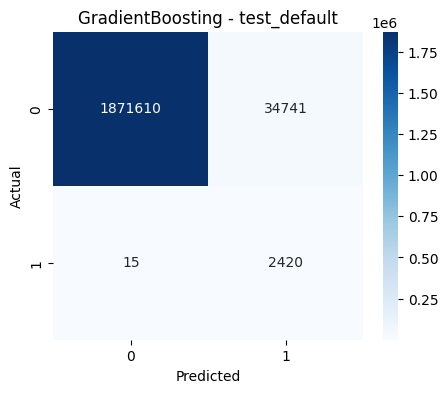

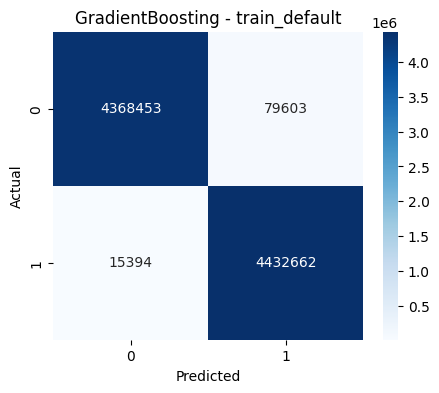


>> Menilai Menggunakan Threshold: OTOMATIS (0.985)
METRICS:
  Accuracy : 0.9995
  Precision: 0.865
  Recall   : 0.7446
  AUC Score: 0.9974
  F1 Test  : 0.8003
  F1 Train : 0.8608

  Classification Report (otomatis):
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998   1906351
           1     0.8650    0.7446    0.8003      2435

    accuracy                         0.9995   1908786
   macro avg     0.9323    0.8722    0.9000   1908786
weighted avg     0.9995    0.9995    0.9995   1908786



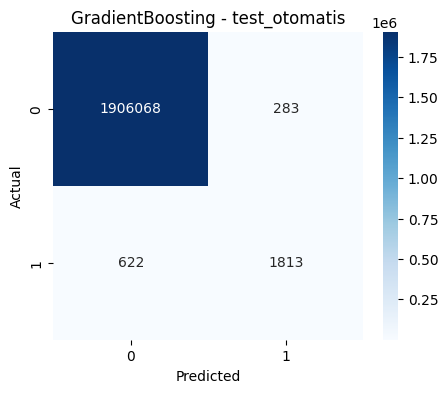

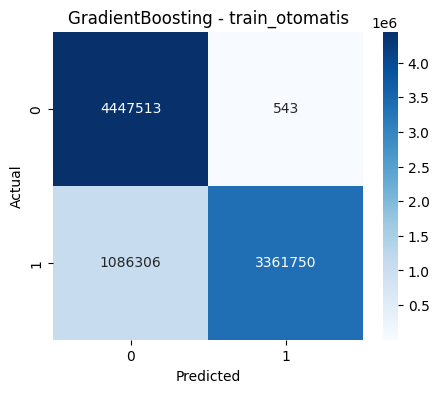


>> Menilai Menggunakan Threshold: MANUAL (0.987)
METRICS:
  Accuracy : 0.9996
  Precision: 0.9213
  Recall   : 0.7257
  AUC Score: 0.9974
  F1 Test  : 0.8119
  F1 Train : 0.8476

  Classification Report (manual):
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998   1906351
           1     0.9213    0.7257    0.8119      2435

    accuracy                         0.9996   1908786
   macro avg     0.9605    0.8628    0.9058   1908786
weighted avg     0.9995    0.9996    0.9995   1908786



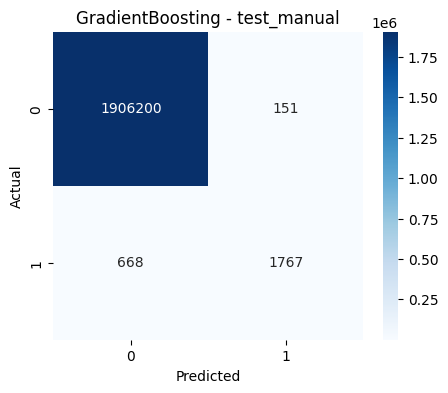

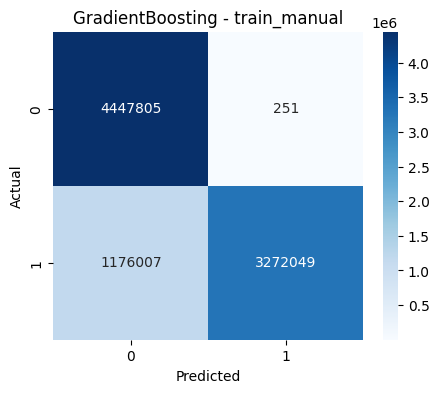


== XGBoost ==

>> Menilai Menggunakan Threshold: DEFAULT (0.5)
METRICS:
  Accuracy : 0.997
  Precision: 0.2937
  Recall   : 0.9803
  AUC Score: 0.9935
  F1 Test  : 0.452
  F1 Train : 0.9986

  Classification Report (default):
              precision    recall  f1-score   support

           0     1.0000    0.9970    0.9985   1906351
           1     0.2937    0.9803    0.4520      2435

    accuracy                         0.9970   1908786
   macro avg     0.6468    0.9886    0.7252   1908786
weighted avg     0.9991    0.9970    0.9978   1908786



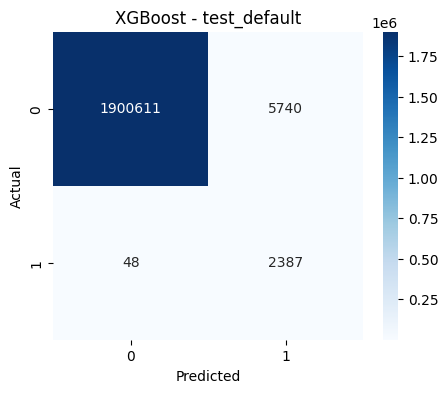

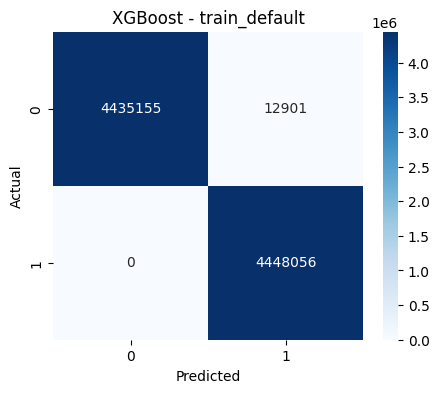


>> Menilai Menggunakan Threshold: OTOMATIS (0.99)
METRICS:
  Accuracy : 0.9993
  Precision: 0.6937
  Recall   : 0.8304
  AUC Score: 0.9935
  F1 Test  : 0.7559
  F1 Train : 0.923

  Classification Report (otomatis):
              precision    recall  f1-score   support

           0     0.9998    0.9995    0.9997   1906351
           1     0.6937    0.8304    0.7559      2435

    accuracy                         0.9993   1908786
   macro avg     0.8467    0.9150    0.8778   1908786
weighted avg     0.9994    0.9993    0.9993   1908786



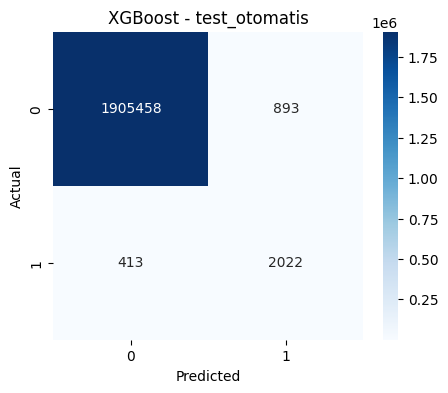

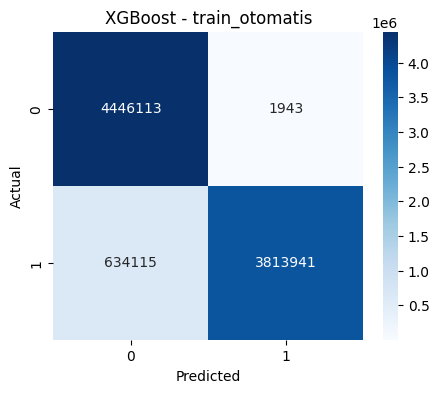


>> Menilai Menggunakan Threshold: MANUAL (0.9929999709129333)
METRICS:
  Accuracy : 0.9994
  Precision: 0.7306
  Recall   : 0.793
  AUC Score: 0.9935
  F1 Test  : 0.7605
  F1 Train : 0.899

  Classification Report (manual):
              precision    recall  f1-score   support

           0     0.9997    0.9996    0.9997   1906351
           1     0.7306    0.7930    0.7605      2435

    accuracy                         0.9994   1908786
   macro avg     0.8652    0.8963    0.8801   1908786
weighted avg     0.9994    0.9994    0.9994   1908786



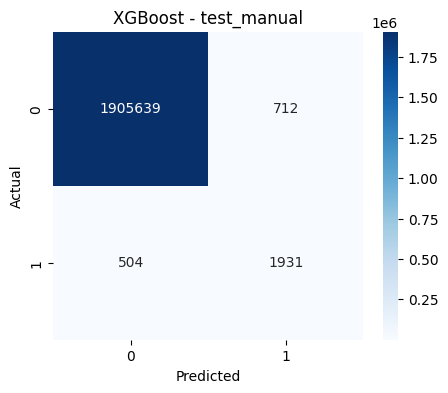

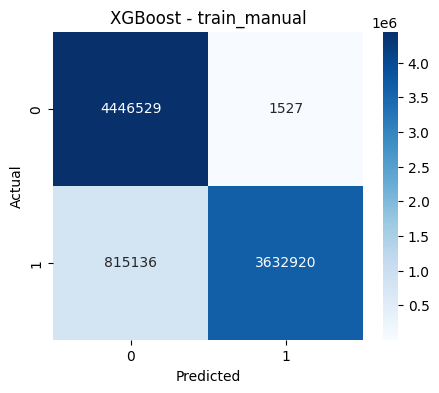


== XGBoostLinear ==

>> Menilai Menggunakan Threshold: DEFAULT (0.5)
METRICS:
  Accuracy : 0.9391
  Precision: 0.0188
  Recall   : 0.9117
  AUC Score: 0.9849
  F1 Test  : 0.0368
  F1 Train : 0.9298

  Classification Report (default):
              precision    recall  f1-score   support

           0     0.9999    0.9392    0.9686   1906351
           1     0.0188    0.9117    0.0368      2435

    accuracy                         0.9391   1908786
   macro avg     0.5093    0.9254    0.5027   1908786
weighted avg     0.9986    0.9391    0.9674   1908786



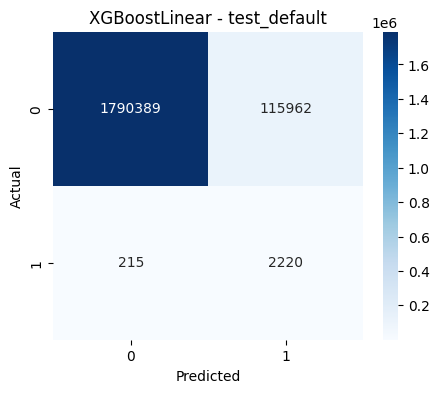

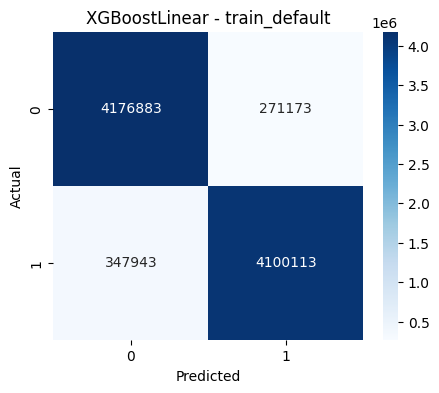


>> Menilai Menggunakan Threshold: OTOMATIS (0.99)
METRICS:
  Accuracy : 0.9985
  Precision: 0.4305
  Recall   : 0.4374
  AUC Score: 0.9849
  F1 Test  : 0.4339
  F1 Train : 0.6116

  Classification Report (otomatis):
              precision    recall  f1-score   support

           0     0.9993    0.9993    0.9993   1906351
           1     0.4305    0.4374    0.4339      2435

    accuracy                         0.9985   1908786
   macro avg     0.7149    0.7183    0.7166   1908786
weighted avg     0.9986    0.9985    0.9985   1908786



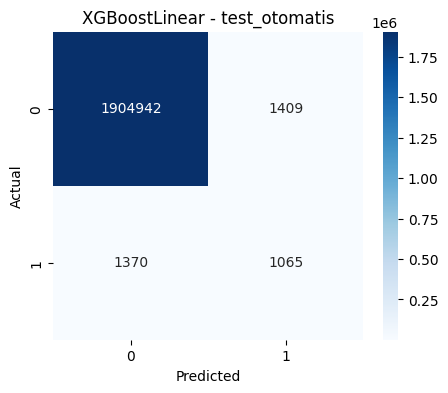

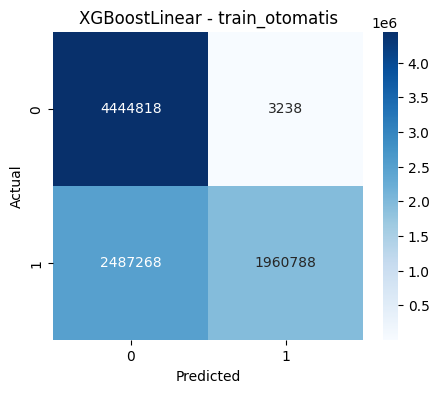


>> Menilai Menggunakan Threshold: MANUAL (0.9980000257492065)
METRICS:
  Accuracy : 0.9989
  Precision: 0.6201
  Recall   : 0.3721
  AUC Score: 0.9849
  F1 Test  : 0.4651
  F1 Train : 0.545

  Classification Report (manual):
              precision    recall  f1-score   support

           0     0.9992    0.9997    0.9995   1906351
           1     0.6201    0.3721    0.4651      2435

    accuracy                         0.9989   1908786
   macro avg     0.8097    0.6859    0.7323   1908786
weighted avg     0.9987    0.9989    0.9988   1908786



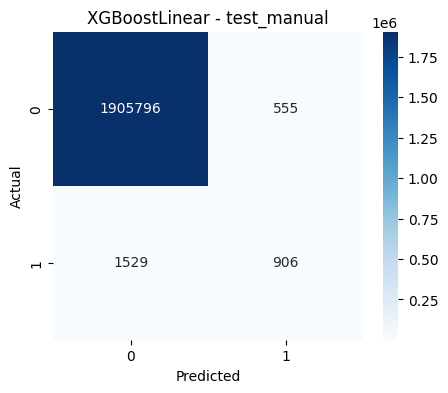

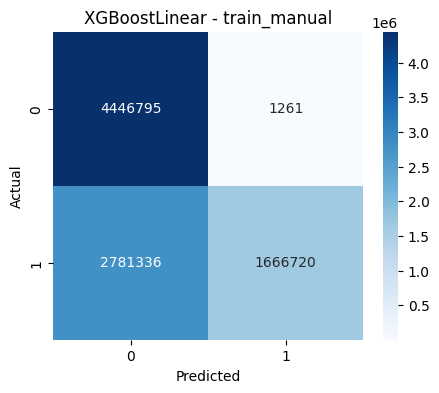


== LightGBM ==

>> Menilai Menggunakan Threshold: DEFAULT (0.5)


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


METRICS:
  Accuracy : 0.9965
  Precision: 0.2649
  Recall   : 0.9955
  AUC Score: 0.9993
  F1 Test  : 0.4184
  F1 Train : 0.9983

  Classification Report (default):
              precision    recall  f1-score   support

           0     1.0000    0.9965    0.9982   1906351
           1     0.2649    0.9955    0.4184      2435

    accuracy                         0.9965   1908786
   macro avg     0.6324    0.9960    0.7083   1908786
weighted avg     0.9991    0.9965    0.9975   1908786



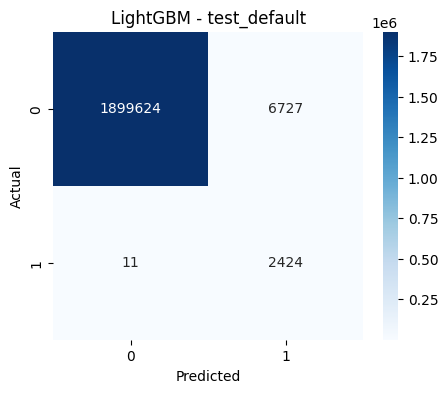

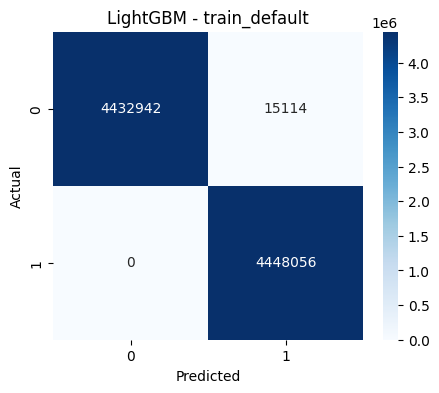


>> Menilai Menggunakan Threshold: OTOMATIS (0.99)


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


METRICS:
  Accuracy : 0.9996
  Precision: 0.8841
  Recall   : 0.8086
  AUC Score: 0.9993
  F1 Test  : 0.8447
  F1 Train : 0.8978

  Classification Report (otomatis):
              precision    recall  f1-score   support

           0     0.9998    0.9999    0.9998   1906351
           1     0.8841    0.8086    0.8447      2435

    accuracy                         0.9996   1908786
   macro avg     0.9420    0.9042    0.9223   1908786
weighted avg     0.9996    0.9996    0.9996   1908786



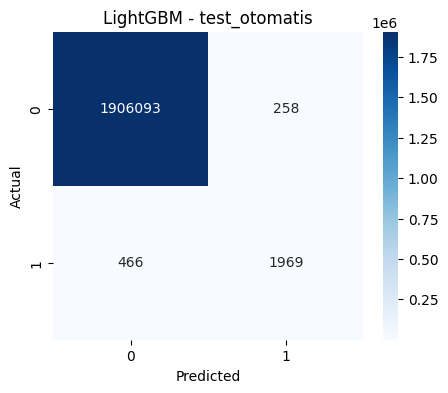

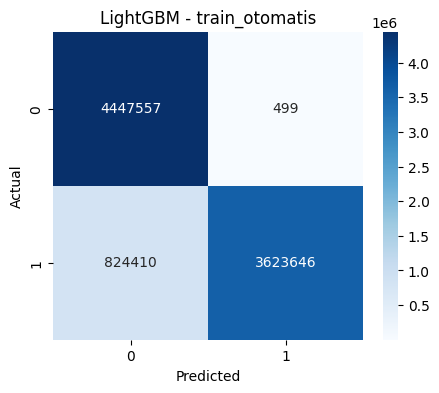


>> Menilai Menggunakan Threshold: MANUAL (0.994)


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


METRICS:
  Accuracy : 0.9997
  Precision: 0.9436
  Recall   : 0.7758
  AUC Score: 0.9993
  F1 Test  : 0.8515
  F1 Train : 0.8802

  Classification Report (manual):
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998   1906351
           1     0.9436    0.7758    0.8515      2435

    accuracy                         0.9997   1908786
   macro avg     0.9716    0.8879    0.9257   1908786
weighted avg     0.9996    0.9997    0.9996   1908786



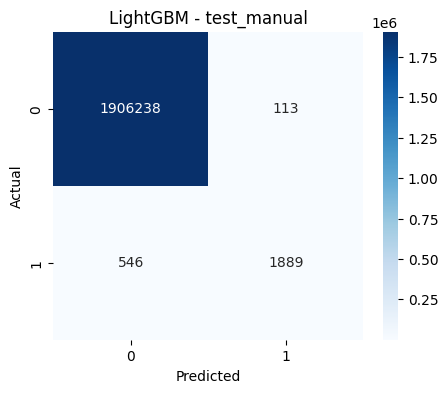

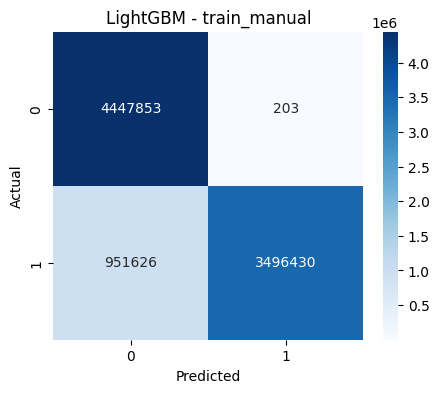


== LightGBM_RF ==

>> Menilai Menggunakan Threshold: DEFAULT (0.5)


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


METRICS:
  Accuracy : 0.9868
  Precision: 0.0876
  Recall   : 0.9955
  AUC Score: 0.9985
  F1 Test  : 0.161
  F1 Train : 0.9916

  Classification Report (default):
              precision    recall  f1-score   support

           0     1.0000    0.9868    0.9933   1906351
           1     0.0876    0.9955    0.1610      2435

    accuracy                         0.9868   1908786
   macro avg     0.5438    0.9911    0.5772   1908786
weighted avg     0.9988    0.9868    0.9923   1908786



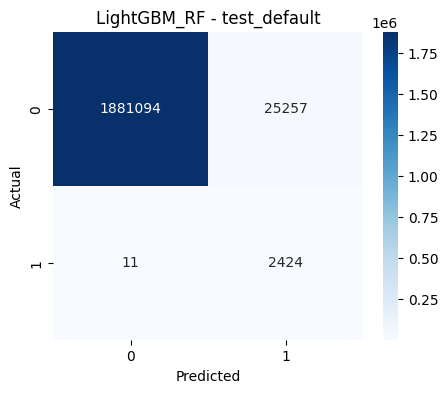

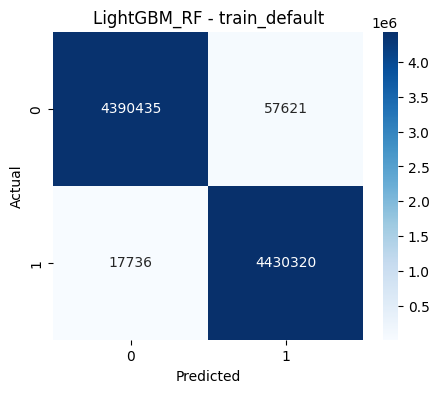


>> Menilai Menggunakan Threshold: OTOMATIS (0.867)


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


METRICS:
  Accuracy : 0.9996
  Precision: 0.9648
  Recall   : 0.6986
  AUC Score: 0.9985
  F1 Test  : 0.8104
  F1 Train : 0.8335

  Classification Report (otomatis):
              precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998   1906351
           1     0.9648    0.6986    0.8104      2435

    accuracy                         0.9996   1908786
   macro avg     0.9822    0.8493    0.9051   1908786
weighted avg     0.9996    0.9996    0.9995   1908786



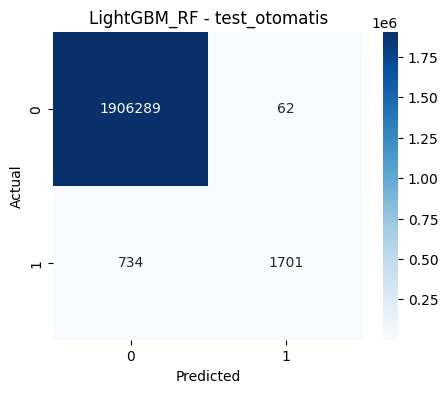

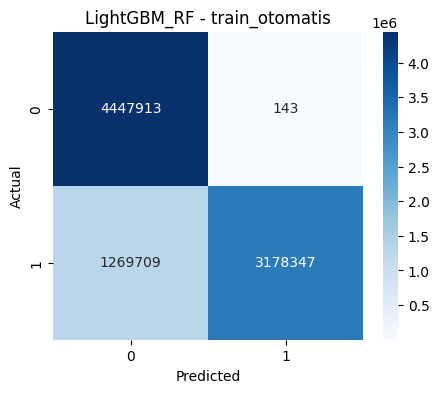


>> Menilai Menggunakan Threshold: MANUAL (0.868)


/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/spyder-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


METRICS:
  Accuracy : 0.9996
  Precision: 0.9924
  Recall   : 0.694
  AUC Score: 0.9985
  F1 Test  : 0.8168
  F1 Train : 0.8301

  Classification Report (manual):
              precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998   1906351
           1     0.9924    0.6940    0.8168      2435

    accuracy                         0.9996   1908786
   macro avg     0.9960    0.8470    0.9083   1908786
weighted avg     0.9996    0.9996    0.9996   1908786



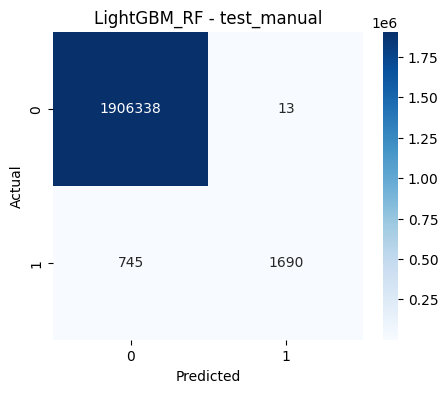

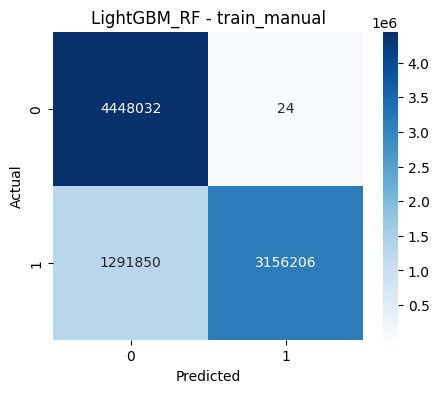

In [18]:
print("\n[FINAL EVALUATION]")

for name, model in trained_models.items():
    print("\n==============================")
    print("==", name, "==")
    print("==============================")

    # Lakukan looping untuk setiap jenis threshold yang disimpan
    for t_type, t_value in thresholds[name].items():
        print(f"\n>> Menilai Menggunakan Threshold: {t_type.upper()} ({round(t_value, 3)})")

        proba_test = model.predict_proba(X_test)[:, 1]
        pred_test = (proba_test >= t_value).astype(int)

        proba_train = model.predict_proba(X_train_resampled)[:, 1]
        pred_train = (proba_train >= t_value).astype(int)

        acc = accuracy_score(y_test, pred_test)
        prec = precision_score(y_test, pred_test)
        rec = recall_score(y_test, pred_test)
        f1 = f1_score(y_test, pred_test)
        f1_train = f1_score(y_train_resampled, pred_train)
        
        auc_score = 0.0
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
            auc_score = roc_auc_score(y_test, y_proba)

        print("METRICS:")
        print("  Accuracy :", round(acc, 4))
        print("  Precision:", round(prec, 4))
        print("  Recall   :", round(rec, 4))
        print("  AUC Score:", round(auc_score, 4))
        print("  F1 Test  :", round(f1, 4))
        print("  F1 Train :", round(f1_train, 4))

        # Jika dirasa terlalu penuh, classification report & plot_cm bisa ditaruh 
        # di luar loop threshold atau hanya dijalankan untuk t_type == 'manual' saja.
        print(f"\n  Classification Report ({t_type}):")
        print(classification_report(y_test, pred_test, digits=4))

        cm_test = confusion_matrix(y_test, pred_test)
        cm_train = confusion_matrix(y_train_resampled, pred_train)

        plot_cm(cm_test, name, f"test_{t_type}")
        plot_cm(cm_train, name, f"train_{t_type}")

    # Eksport model cukup sekali saja per tipe model (di luar loop threshold)
    joblib.dump(model, f"{name}_final.pkl")